In [45]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy.stats
import seaborn as sns

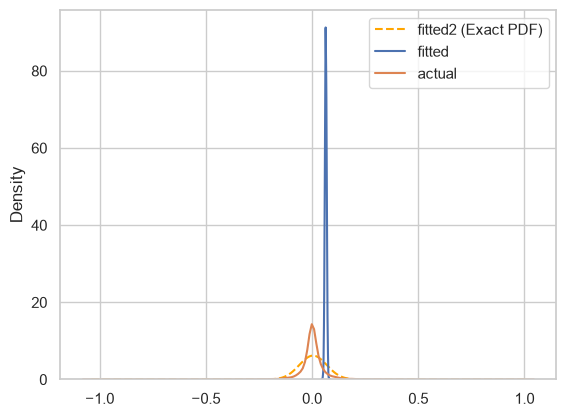

In [46]:
path = "/Users/zipp/Desktop/programming/ml-training/data/bitcoin_dataset.csv"
df = (
    pl.read_csv(path, infer_schema_length=2908)
    .rename(lambda s: s.lower())
    .select(pl.col("date").str.to_datetime(r"%m/%d/%Y %H:%M"), "btc_market_price")
    .sort(by="date", descending=False)
)
data = df.get_column("btc_market_price").to_numpy()[182:]
data = np.diff(np.log(data), 1)
mean, std = scipy.stats.norm.fit(data)
fitted_data = np.random.normal(scale=mean, loc=std, size=len(data))
fitted_data2 = scipy.stats.norm.pdf(data, mean, std)
x_axis = np.linspace(data.min(), data.max(), 1000)
pdf_y_values = scipy.stats.norm.pdf(x_axis, mean, std)
plt.plot(
    x_axis, pdf_y_values, label="fitted2 (Exact PDF)", color="orange", linestyle="--"
)
sns.kdeplot(fitted_data, label="fitted")
sns.kdeplot(data, label="actual")
plt.legend()

58941.7123675 60588.5798575


<Axes: ylabel='Count'>

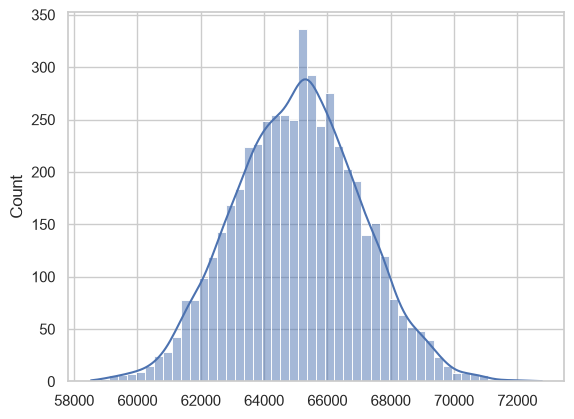

In [47]:
rng = np.random.default_rng(None)
base = rng.integers(30000, 100000, 10000)
samples = rng.choice(base, size=(5000, 100))
sample_means = samples.mean(axis=1)
sample_means, sample_means.shape
conf_level = 0.05
lower_bound = conf_level / 2
upper_bound = 1 - lower_bound
print(
    np.percentile(sample_means, lower_bound), np.percentile(sample_means, upper_bound)
)
sns.histplot(sample_means, kde=True, bins=50)

In [48]:
rng = np.random.default_rng(None)
base = rng.integers(30000, 100000, 10000)
samples = rng.choice(base, size=(5000, 500))
sample_means = np.sort(samples.mean(axis=1))
conf_level = 0.05
lower_bound = conf_level / 2
upper_bound = 1 - lower_bound
quant_2_5 = np.percentile(sample_means, lower_bound)
quant_97_5 = np.percentile(sample_means, upper_bound)
lower_val, upper_val = np.percentile(sample_means, [lower_bound, upper_bound])

# 3. Find their indexes in the sorted array
lower_idx = np.searchsorted(sample_means, lower_val)
upper_idx = np.searchsorted(sample_means, upper_val)
lower_idx, upper_idx
sample_means[lower_idx - 1 : upper_idx], quant_2_5, quant_97_5

(array([62025.444, 62079.942, 62086.064, 62127.222, 62137.212, 62180.224,
        62196.854, 62197.182, 62296.506, 62301.63 , 62345.612, 62432.86 ,
        62433.726, 62503.166, 62514.706, 62538.28 , 62549.398, 62553.06 ,
        62651.546, 62660.936, 62684.368, 62685.792, 62700.172, 62743.368,
        62750.246, 62758.816, 62764.758, 62766.89 , 62767.53 , 62776.91 ,
        62782.326, 62783.752, 62804.684, 62825.67 , 62830.872, 62834.858,
        62836.764, 62856.322, 62856.424, 62858.87 , 62861.866, 62868.21 ,
        62876.36 , 62876.366, 62895.31 , 62900.166, 62900.31 , 62908.834]),
 np.float64(62039.054875500005),
 np.float64(62912.011153))

((array([-3.63568806, -3.40036853, -3.27067228, ...,  3.27067228,
          3.40036853,  3.63568806], shape=(5000,)),
  array([61920.76 , 62025.444, 62079.942, ..., 68186.072, 68441.002,
         68448.186], shape=(5000,))),
 (np.float64(908.6391575183369),
  np.float64(65021.15576359999),
  np.float64(0.9998275649475447)))

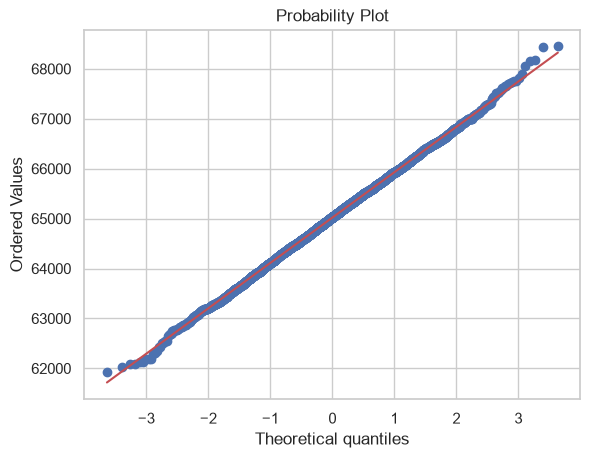

In [49]:
import scipy.stats

scipy.stats.probplot(sample_means, dist="norm", plot=plt)

In [50]:
scipy.stats.norm.interval(0.95, loc=sample_means.mean(), scale=sample_means.std())

(np.float64(63241.1369602191), np.float64(66801.17456698089))

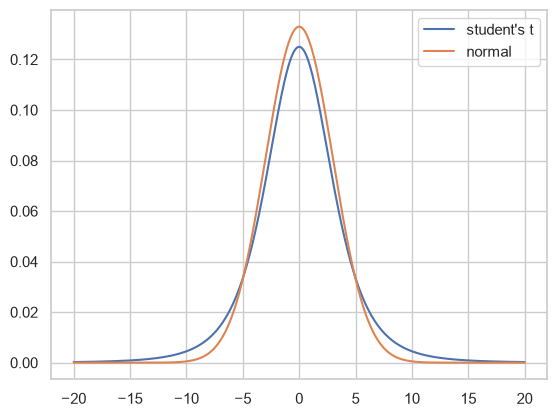

In [51]:
x = np.linspace(-20, 20.0, 1000)
y = scipy.stats.t.pdf(x, 4, loc=0, scale=3)
y2 = scipy.stats.norm.pdf(x, loc=0, scale=3)
sns.lineplot(x=x, y=y, label="student's t")
sns.lineplot(x=x, y=y2, label="normal")
plt.legend()

(np.float64(0.4113512395595057),
 np.float64(0.5886487604404943),
 np.float64(1.0),
 np.float64(0.9983447645640207))

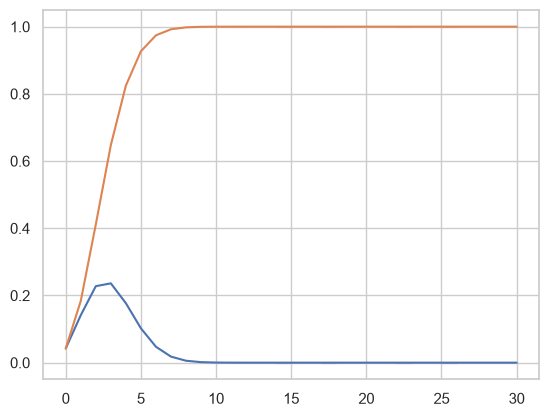

In [52]:
x = np.linspace(0, 30, dtype=np.uint8)
prob = scipy.stats.binom.pmf(x, 30, 0.1)
cum_prob = scipy.stats.binom.cdf(x, 30, 0.1)
prob
sns.lineplot(x=x, y=prob)
sns.lineplot(x=x, y=cum_prob)
(
    scipy.stats.binom.cdf(2, 30, 0.1),
    scipy.stats.binom.sf(2, 30, 0.1),
    scipy.stats.binom.cdf(2, 30, 0.1) + scipy.stats.binom.sf(2, 30, 0.1),
    prob.mean() * 30,
)

8.0


<Axes: >

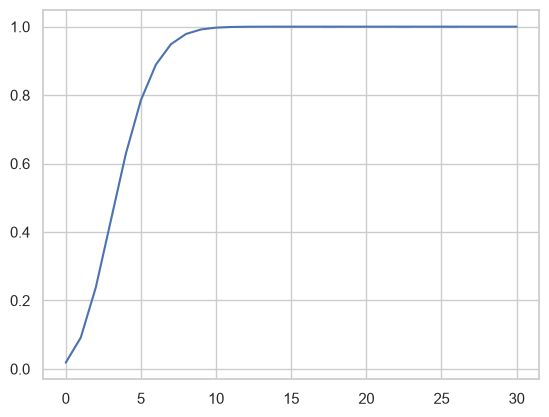

In [53]:
quant = scipy.stats.poisson.ppf(0.95, mu=4)
print(quant)
x = np.linspace(0, 30, dtype=np.uint8)
samples = scipy.stats.poisson.cdf(x, mu=4)
samples
sns.lineplot(x=x, y=samples)

Prob of arriving in under 30 mins: 86.47%
Prob of waiting over 1 hour: 1.83%
90% of waits are under 0.58 hours
Simulated waits (hours): [0.28087099 0.10363005 0.01369777 0.30544146 0.2377144 ]


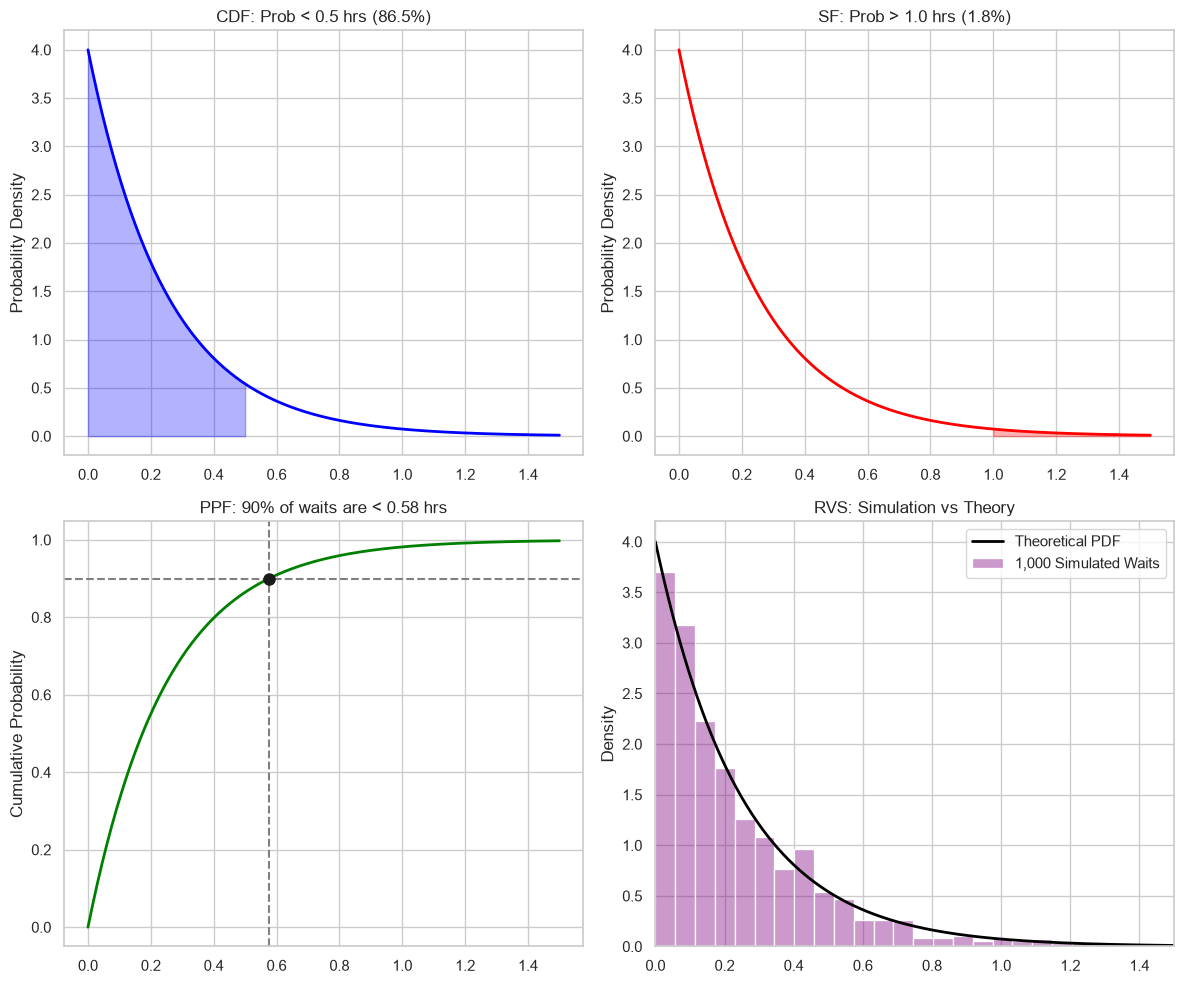

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import expon

# --- 1. CORE CALCULATIONS ---
rate = 4
wait_time = 1 / rate  # 0.25 hours

# 2. Cumulative Distribution Function (CDF)
prob_quick = expon.cdf(x=0.5, scale=wait_time)
print(f"Prob of arriving in under 30 mins: {prob_quick:.2%}")

# 3. Survival Function (SF)
prob_long = expon.sf(x=1.0, scale=wait_time)
print(f"Prob of waiting over 1 hour: {prob_long:.2%}")

# 4. Percent Point Function (PPF)
ninety_percentile = expon.ppf(q=0.90, scale=wait_time)
print(f"90% of waits are under {ninety_percentile:.2f} hours")

# 5. Random Variates (RVS)
simulated_waits = expon.rvs(scale=wait_time, size=5)
print(f"Simulated waits (hours): {simulated_waits}")


# --- 2. VISUALIZATION ---
sns.set_theme(style="whitegrid")

# Create a master x-axis of theoretical wait times (0 to 1.5 hours)
x_vals = np.linspace(0, 1.5, 500)
pdf_vals = expon.pdf(x_vals, scale=wait_time)
cdf_vals = expon.cdf(x_vals, scale=wait_time)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: CDF (Area under the curve up to 0.5)
axes[0, 0].plot(x_vals, pdf_vals, color="blue", lw=2)
x_fill_cdf = np.linspace(0, 0.5, 100)
axes[0, 0].fill_between(
    x_fill_cdf, expon.pdf(x_fill_cdf, scale=wait_time), color="blue", alpha=0.3
)
axes[0, 0].set_title(f"CDF: Prob < 0.5 hrs ({prob_quick:.1%})")
axes[0, 0].set_ylabel("Probability Density")

# Plot 2: SF (Area under the curve beyond 1.0)
axes[0, 1].plot(x_vals, pdf_vals, color="red", lw=2)
x_fill_sf = np.linspace(1.0, 1.5, 100)
axes[0, 1].fill_between(
    x_fill_sf, expon.pdf(x_fill_sf, scale=wait_time), color="red", alpha=0.3
)
axes[0, 1].set_title(f"SF: Prob > 1.0 hrs ({prob_long:.1%})")
axes[0, 1].set_ylabel("Probability Density")

# Plot 3: PPF (Tracing the Cumulative curve to 90%)
axes[1, 0].plot(x_vals, cdf_vals, color="green", lw=2)
axes[1, 0].axhline(0.90, color="gray", linestyle="--")
axes[1, 0].axvline(ninety_percentile, color="gray", linestyle="--")
axes[1, 0].plot(ninety_percentile, 0.90, "ko", markersize=8)  # Target dot
axes[1, 0].set_title(f"PPF: 90% of waits are < {ninety_percentile:.2f} hrs")
axes[1, 0].set_ylabel("Cumulative Probability")

# Plot 4: RVS (Simulating 1,000 real patients vs Theoretical curve)
# We use 1,000 here instead of 5 so the histogram forms a visible shape
sim_large = expon.rvs(scale=wait_time, size=1000)
sns.histplot(
    sim_large,
    bins=30,
    stat="density",
    alpha=0.4,
    color="purple",
    ax=axes[1, 1],
    label="1,000 Simulated Waits",
)
axes[1, 1].plot(x_vals, pdf_vals, color="black", lw=2, label="Theoretical PDF")
axes[1, 1].set_xlim(0, 1.5)
axes[1, 1].set_title("RVS: Simulation vs Theory")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

np.float64(0.04639200646475444)

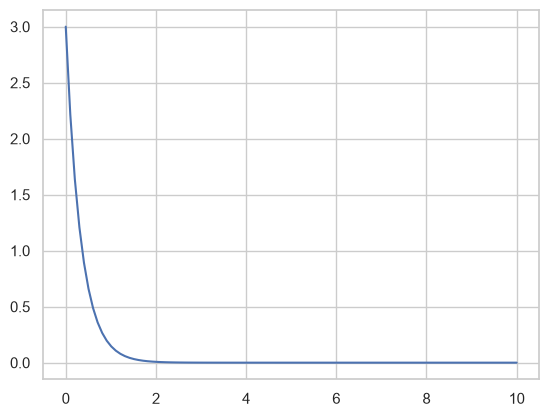

In [62]:
poisson_mean = 3
exp_mean = 1 / poisson_mean


def min_to_h(min: float) -> float:
    return min / 60


x = np.linspace(0, 10, 100)
y = scipy.stats.expon.pdf(x, scale=exp_mean)
sns.lineplot(x=x, y=y)
(
    scipy.stats.expon.cdf(min_to_h(10), scale=exp_mean),
    scipy.stats.expon.sf(min_to_h(29.999), scale=exp_mean),
    np.diff(
        scipy.stats.expon.cdf(
            np.array([min_to_h(14.999), min_to_h(15.001)]), scale=exp_mean
        )
    ),
)
scipy.stats.expon.cdf(min_to_h(2), scale=exp_mean) - scipy.stats.expon.cdf(
    min_to_h(1), scale=exp_mean
)